In [5]:
import numpy as np
import matplotlib.pyplot as plt
import kwant

from scipy.constants import physical_constants

In [6]:
#a = 1.0 * 10**(-9)
#N = 49
#L = (N+1)*a
#print("L=", L, "m")
#print(" <moduleL=", L/a, "nm") we change a and N to have more precise plots
a = 0.5 * 10**(-9)
a_nm = a * 10 ** 9 #so the lattice looks decent
N = 40
L = (N+1)*a
L_nm = L * 10 ** 9
print("L=", L, "m")
print(" <moduleL=", L/a, "nm")

L= 2.05e-08 m
 <moduleL= 41.0 nm


In [7]:
h_bar = physical_constants['Planck constant over 2 pi'][0]
eV_unit = physical_constants['electron volt'][0]
m_el = physical_constants['electron mass'][0]

In [8]:
t = (h_bar**2) / (2*m_el*(a**2))
t = t / eV_unit

print("t=", t)

t= 0.15239927954599816


In [9]:
sys = kwant.Builder()

In [10]:
lat = kwant.lattice.square(a_nm)

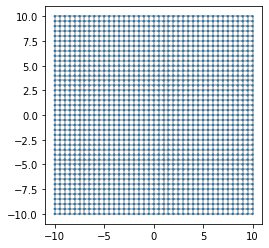

In [11]:
#first we determine a func. which will determine the system, meaning:
#function which extracts coordinates,checks if the point is inside our lattice square whith sides = L_nm and center (0, 0)
#pos-position
def square_shape(pos):
    (x, y) = pos
    if(x < L_nm/2 and x > -L_nm/2 and y < L_nm/2 and y > -L_nm/2):#quiceker way if abs(y)<L_nm/2 and abs(x)<L_nm/2 no need for else
        return True
    else:
        return False
sys[lat.shape(square_shape, (0,0))] = 4 * t   
sys[lat.neighbors()] = -t

kwant.plot(sys);

In [12]:
sysf = sys.finalized()

In [13]:
Hmat = sysf.hamiltonian_submatrix()

In [14]:
ene, v = np.linalg.eigh(Hmat)

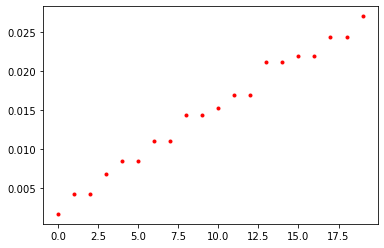

In [15]:
plt.plot(ene[:20], "r."); #it will take some time since we have 99^2 ops

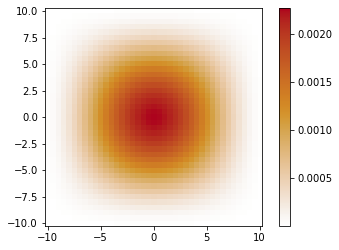

In [16]:
#now we plot
kwant.plotter.map(sysf, abs(v[:,0])**2);

In [17]:
from ipywidgets import interact

In [18]:
def plot_wf(n=0):
    kwant.plotter.map(sysf, abs(v[:,n])**2);

In [19]:
interact(plot_wf, n=(0,40))

interactive(children=(IntSlider(value=0, description='n', max=40), Output()), _dom_classes=('widget-interact',…

<function __main__.plot_wf(n=0)>